In [1]:

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import cv2
import os

base = '/content/drive/MyDrive/KemikAI'

# Yeni multimodal modeli yükle
model = keras.models.load_model(f'{base}/models/kemikai_multimodal_best.keras')
print("✅ Model yüklendi!")

Mounted at /content/drive
✅ Model yüklendi!


In [4]:
# Veri hazırla
df = pd.read_csv('/content/drive/MyDrive/KemikAI/data/raw/RSNA_Annotations/RSNA_Annotations/BONEAGE/boneage_train.csv')
df['gender'] = df['Male'].apply(lambda x: 1 if x else 0)

def generate_synthetic_clinical_data(df):
    df = df.copy()
    age_y = df['Boneage'] / 12.0
    df['height_cm'] = np.random.normal(70 + (age_y * 6), 5).clip(50, 200)
    df['weight_kg'] = np.random.normal(10 + (age_y * 2.5), 3).clip(3, 120)
    df['mother_height'] = np.random.normal(162, 6, size=len(df)).clip(145, 185)
    df['father_height'] = np.random.normal(175, 7, size=len(df)).clip(160, 195)
    df['vit_d_deficiency'] = np.random.choice([0, 1], p=[0.8, 0.2], size=len(df))
    df['calcium_level'] = np.random.choice([0, 1, 2], p=[0.1, 0.8, 0.1], size=len(df))
    df['fracture_history'] = np.random.choice([0, 1], p=[0.85, 0.15], size=len(df))
    return df

df = generate_synthetic_clinical_data(df)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

continuous_cols = ['height_cm', 'weight_kg', 'mother_height', 'father_height']
categorical_cols = ['gender', 'vit_d_deficiency', 'calcium_level', 'fracture_history']
tabular_cols = continuous_cols + categorical_cols

scaler = StandardScaler()
train_df[continuous_cols] = scaler.fit_transform(train_df[continuous_cols])
val_df[continuous_cols] = scaler.transform(val_df[continuous_cols])

def gradcam_heatmap(model, img_tensor, tabular_tensor, layer_name='top_activation'):
    # Tabular'ı da tf.tensor yap
    tabular_tensor = tf.convert_to_tensor(tabular_tensor, dtype=tf.float32)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(
            {'image_input': img_tensor, 'tabular_input': tabular_tensor}
        )
        loss = predictions[0][0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

print("✅ Düzeltildi!")
def show_gradcam(image_path, tabular_row, gercek_ay=None):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32)
    img_batch = tf.expand_dims(img, axis=0)
    tabular_batch = np.expand_dims(tabular_row[tabular_cols].values.astype(np.float32), axis=0)

    pred = model.predict({'image_input': img_batch, 'tabular_input': tabular_batch}, verbose=0)[0][0]

    heatmap = gradcam_heatmap(model, img_batch, tabular_batch)
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    orig = img.numpy().astype(np.uint8)
    overlay = cv2.addWeighted(orig, 0.6, heatmap_color, 0.4, 0)

    if gercek_ay:
        fark = pred - gercek_ay
        if abs(fark) <= 6:
            durum = "✅ Normal Gelişim"
        elif fark < -6:
            durum = f"⚠️ Geride ({abs(fark):.0f} ay)"
        else:
            durum = f"📈 İleride ({fark:.0f} ay)"

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(orig)
    axes[0].set_title('Orijinal Röntgen')
    axes[0].axis('off')

    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title('GradCAM Isı Haritası')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    title = f'Tahmin: {pred:.0f} ay ({pred/12:.1f} yıl)'
    if gercek_ay:
        title += f'\nGerçek: {gercek_ay} ay | {durum}'
    axes[2].set_title(title)
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(f'{base}/outputs/gradcam/gradcam_multimodal.png')
    plt.show()
    return pred

print("✅ Hazır!")

✅ Düzeltildi!
✅ Hazır!


Test görüntüsü ID: 14675
Gerçek kemik yaşı: 132 ay (11.0 yıl)
Cinsiyet: Erkek


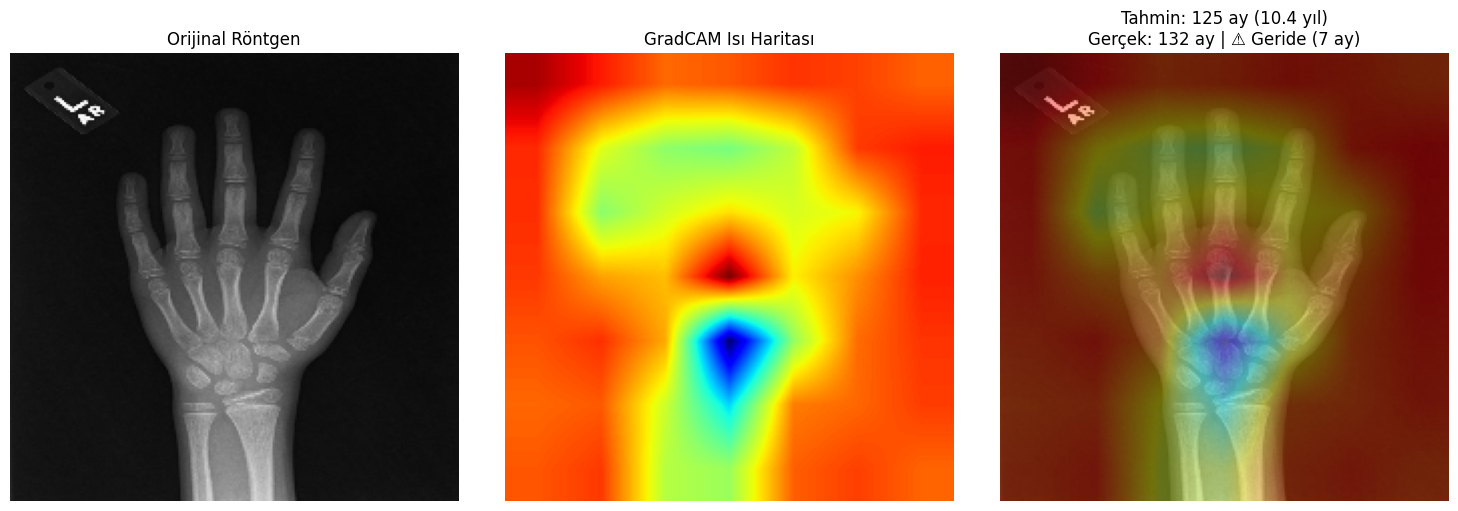


Tahmin: 125 ay (10.4 yıl)


In [5]:
# Rastgele bir görüntü seç
sample = val_df.sample(1, random_state=42).iloc[0]
img_path = f'/content/train_images/{int(sample.ID)}.png'

if not os.path.exists(img_path):
    img_path = f'/content/drive/MyDrive/KemikAI/data/raw/RSNA_train/images/{int(sample.ID)}.png'

print(f"Test görüntüsü ID: {sample.ID}")
print(f"Gerçek kemik yaşı: {sample.Boneage} ay ({sample.Boneage/12:.1f} yıl)")
print(f"Cinsiyet: {'Erkek' if sample.gender == 1 else 'Kız'}")

pred = show_gradcam(img_path, sample, gercek_ay=sample.Boneage)
print(f"\nTahmin: {pred:.0f} ay ({pred/12:.1f} yıl)")

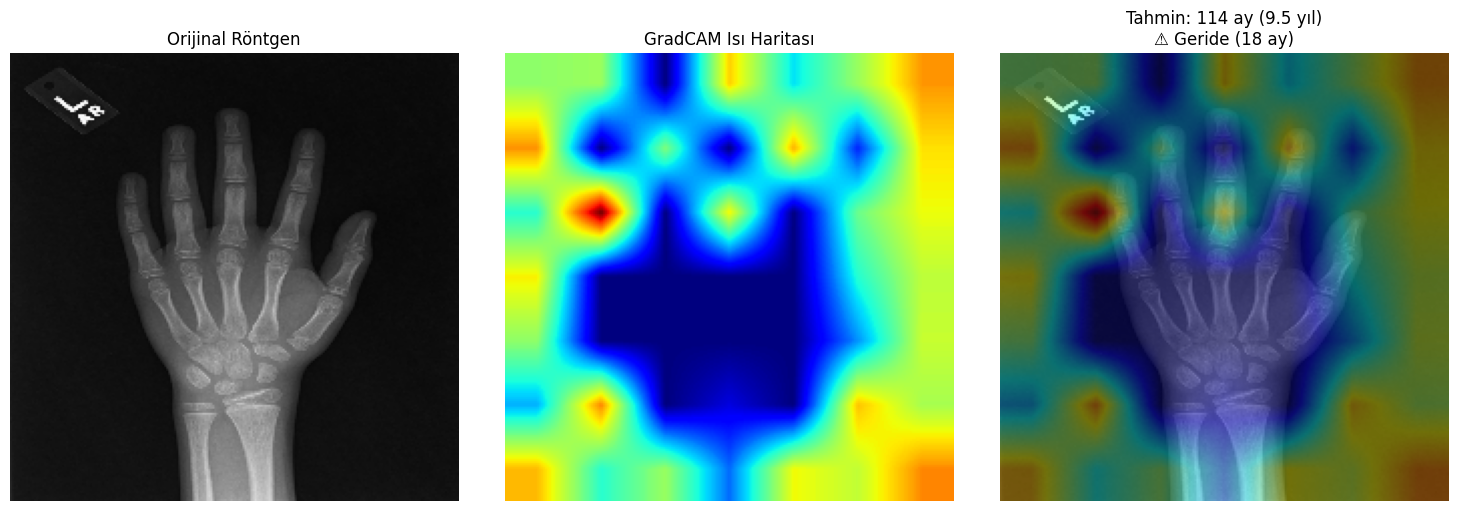


Tahmin: 114 ay (9.5 yıl)


In [ ]:
img_path = f'/content/drive/MyDrive/KemikAI/data/raw/RSNA_train/images/{int(sample.ID)}.png'
pred = show_gradcam(img_path, sample.gender, kronolojik_ay=sample.Boneage)
print(f"\nTahmin: {pred:.0f} ay ({pred/12:.1f} yıl)")